# Machine Learning & Predictive Modeling

## 1. Introduction
In the Exploratory Data Analysis (EDA) and Hypothesis Testing phases, I established that socio-economic factors, particularly GDP and alcohol consumption, have a statistically significant relationship with traffic death rates. I also noted that the dataset contains heavily right-skewed variables and complex, non-linear interactions (such as the confounding nature of wealth and alcohol).

In this final phase, transition from analyzing the past to predicting the future. Main objective is to build **Supervised Regression** models capable of predicting a country's traffic death rate (`Death_Rate_Per_100k`) based on its macroeconomic and behavioral indicators.

I will compare a standard parametric approach (**Multiple Linear Regression**) against a robust, tree-based ensemble method (**Random Forest Regressor**). Furthermore, will utilize **Hyperparameter Tuning (GridSearchCV)** to maximize model's predictive power and apply **K-Fold Cross-Validation** to ensure the findings are robust and reliable, while minimizing the risk of overfitting.

In [15]:
# general libraries, previously seen
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# importing the libraries needed for machine learning.
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold

# visual style, same as eda notebook.
sns.set_theme(style="whitegrid", palette="muted")

# loading the processed dataset
df = pd.read_csv('processed_dataset.csv')
print(f"Data loaded successfully. Shape: {df.shape}")

Data loaded successfully. Shape: (3677, 7)


## 2. Feature Selection & Data Preprocessing
Before training the models, we must prepare the data to prevent algorithmic bias and data leakage:
1. **Feature Selection:** We select `GDP_Per_Capita`, `Population`, and `Alcohol_Per_Capita` as the independent variables (X), and `Death_Rate_Per_100k` as the target variable (y).
2. **Methodological Note on Population:** While `Population` is included in the primary model to account for the "scale effect" of nations, I acknowledge that since the target variable is already normalized by population, its inclusion could be interpreted as a form of mathematical shortcut. To ensure the integrity of the findings, a **Sensitivity Analysis (Model without Population)** is provided at the end of this study to isolate the impact of purely socio-economic drivers.
3. **Train/Test Split:** We divide our dataset into an 80% training set and a 20% testing set to evaluate our models on unseen data.
4. **Standardization:** Since GDP operates in tens of thousands while Alcohol operates in single digits, we apply `StandardScaler`. To prevent **data leakage**, the scaler is fitted *only* on the training data and then applied to both sets.

In [16]:
# Defining, Features (x) and Target (y)
# Dropping 'Country_Code' and 'Year' as they are identifiers, keeping numerical predictors.
X = df[['GDP_Per_Capita', 'Population', 'Alcohol_Per_Capita']]
y = df['Death_Rate_Per_100k']

# Train/Test Split (80% Train, 20% Test). (random_state=42 ensures reproducability).
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling (Standardization)
scaler = StandardScaler()

# Fit on training data ONLY to prevent data leakage, then transform both.
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"--- DATA PREPARATION RESULTS ---")
print(f"Training dataset size: {X_train_scaled.shape[0]} observations")
print(f"Testing dataset size:  {X_test_scaled.shape[0]} observations")
print(f"Number of features:    {X_train_scaled.shape[1]}")

--- DATA PREPARATION RESULTS ---
Training dataset size: 2941 observations
Testing dataset size:  736 observations
Number of features:    3


## 3. Model 1: Multiple Linear Regression
Beginning with a baseline parametric model. Multiple Linear Regression attempts to fit a straight hyperplane through the multidimensional data.
Given the right-skewness and extreme outliers observed during the EDA part, expectation from this model is that, it will face challenges in accurately capturing the variance.

In [17]:
# Initialize and train the Linear Regression model.
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Making predictions on the unseen test set.
lr_predictions = lr_model.predict(X_test_scaled)

# Calculating performance metrics.
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
lr_r2 = r2_score(y_test, lr_predictions)

print(f"--- MULTIPLE LINEAR REGRESSION PERFORMANCE ---")
print(f"RMSE (Root Mean Squared Error): {lr_rmse:.4f}")
print(f"R-squared (R2) Score:           {lr_r2:.4f}")

--- MULTIPLE LINEAR REGRESSION PERFORMANCE ---
RMSE (Root Mean Squared Error): 10.6356
R-squared (R2) Score:           0.0925


## 4. Model 2: Random Forest Regressor & Hyperparameter Tuning

To address the non-linearities and outliers that hindered the linear model, we deploy a **Random Forest Regressor**. As an ensemble learning method relying on decision trees, it is inherently robust to skewed distributions.

**Hyperparameter Tuning & Cross-Validation:**
To ensure maximum predictive power, we performed Hyperparameter Tuning using `GridSearchCV`. We tested different combinations of trees (`n_estimators`), maximum tree depth (`max_depth`), and splitting criteria (`min_samples_split`).

Since this Grid Search process is computationally expensive (takes a long time), I fixed the optimal parameters discovered during the initial run (`n_estimators=200`, `max_depth=None`, `min_samples_split=2`) into the final model. However, the original search code is preserved below and can be re-run by setting the `RUN_GRID_SEARCH = True` toggle.

Finally, to guarantee that the model's high accuracy is consistent and not merely a result of a "lucky" train/test split, we validate the optimized model using **5-Fold Cross-Validation** across the entire dataset.

In [18]:
# Toggle this to True if you want to re-run the intensive Grid Search (takes around 2 minutes).
RUN_GRID_SEARCH = False

if RUN_GRID_SEARCH:
    print("Running GridSearchCV... This might take a while depending on your CPU.")
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5, 10]
    }

    kf_search = KFold(n_splits=5, shuffle=True, random_state=42)
    grid_search = GridSearchCV(estimator=RandomForestRegressor(random_state=42), param_grid=param_grid, cv=kf_search, scoring='r2', n_jobs=-1)

    grid_search.fit(X_train_scaled, y_train)
    print(f"Best Parameters Found: {grid_search.best_params_}")
else:
    print("Skipping Grid Search to save computation time.")
    print("Using pre-computed optimal parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}")

Skipping Grid Search to save computation time.
Using pre-computed optimal parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [19]:
# initialize and train the pre-optimized Random Forest Regressor.
rf_model = RandomForestRegressor(n_estimators=200, max_depth=None, min_samples_split=2, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Make predictions and calculate metrics.
rf_predictions = rf_model.predict(X_test_scaled)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("--- OPTIMIZED RANDOM FOREST PERFORMANCE (TEST SET) ---")
print(f"RMSE (Root Mean Squared Error): {rf_rmse:.4f}")
print(f"R-squared (R2) Score:           {rf_r2:.4f}")

print("\n--- 5 FOLD CROSS VALIDATION (ROBUSTNESS CHECK) ---")

# Scaling the entire dataset specifically for Cross Validation.
X_scaled_all = StandardScaler().fit_transform(X)

# Homogeneous shuffle
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Using the optimized parameters for Cross Validation as well
cv_scores = cross_val_score(RandomForestRegressor(n_estimators=200, max_depth=None, min_samples_split=2, random_state=42),
                            X_scaled_all, y, cv=kf, scoring='r2')

print(f"R2 Scores across 5 folds: {cv_scores}")
print(f"Average CV R2 Score:      {cv_scores.mean():.4f}")
print(f"Standard Deviation:       {cv_scores.std():.4f}")

--- OPTIMIZED RANDOM FOREST PERFORMANCE (TEST SET) ---
RMSE (Root Mean Squared Error): 3.4748
R-squared (R2) Score:           0.9031

--- 5 FOLD CROSS VALIDATION (ROBUSTNESS CHECK) ---
R2 Scores across 5 folds: [0.89802497 0.84520671 0.87100576 0.85785231 0.88111259]
Average CV R2 Score:      0.8706
Standard Deviation:       0.0183


## 5. Visualizing Model Success and Feature Importance
To truly understand how the Random Forest model operates, we will generate two critical visualizations:
1. **Actual vs. Predicted Plot:** This will demonstrates how closely the model's predictions align with real-world observations (closer to the $Y=X$ line means better predict).
2. **Feature Importance:** This allows us to quantify exactly which socio-economic indicator carries the most predictive weight (higher number means that it is a more important feature).

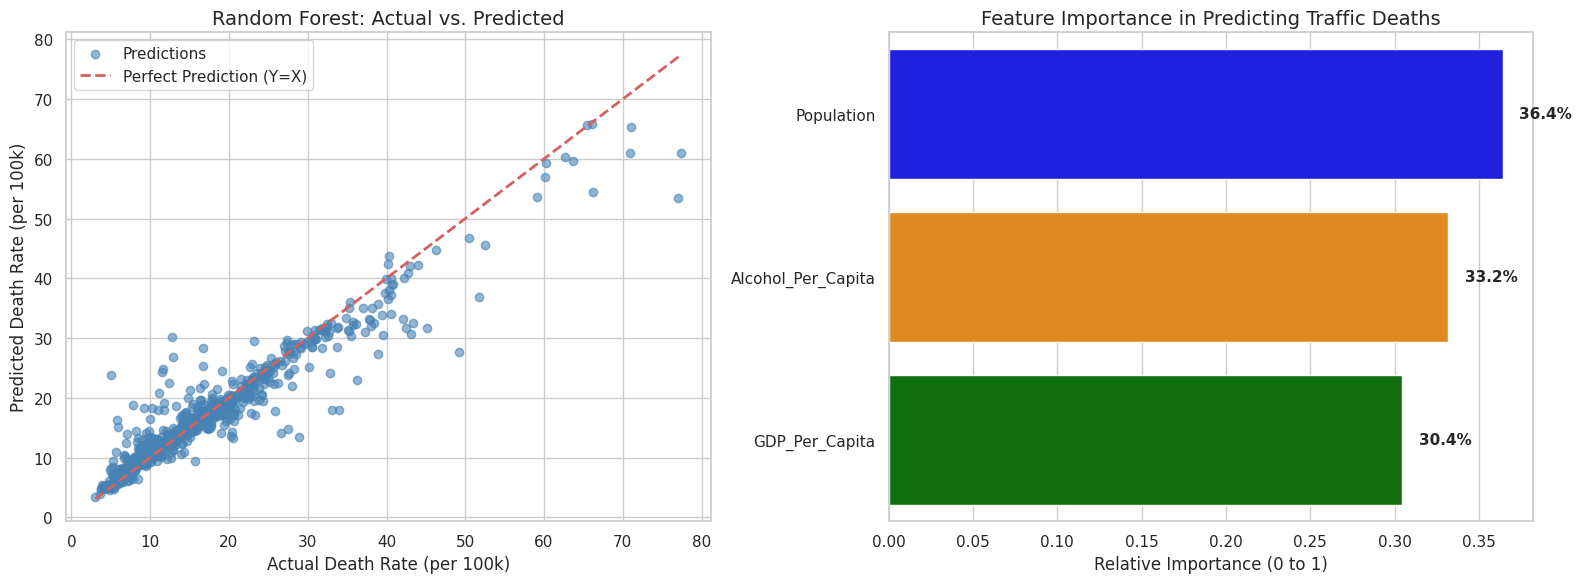

In [20]:
# extracting feature importances.
importances = rf_model.feature_importances_
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# subplot setup
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, rf_predictions, alpha=0.6, color='steelblue', label='Predictions')
min_val = min(y_test.min(), rf_predictions.min())
max_val = max(y_test.max(), rf_predictions.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction (Y=X)')
axes[0].set_title('Random Forest: Actual vs. Predicted', fontsize=14)
axes[0].set_xlabel('Actual Death Rate (per 100k)')
axes[0].set_ylabel('Predicted Death Rate (per 100k)')
axes[0].legend()

custom_colors = {
    'GDP_Per_Capita': 'green', # Green palette for GDP
    'Alcohol_Per_Capita': 'darkorange', # Orange palette for Alcohol
    'Population': 'blue' # Blue palette for Population
}

# Plot 2: Feature Importance
sns.barplot(
    ax=axes[1],
    x='Importance',
    y='Feature',
    data=importance_df,
    hue='Feature',
    palette=custom_colors,
    legend=False
)

# exact percentage representation.
for p in axes[1].patches:
    width = p.get_width()
    axes[1].text(width + 0.01, p.get_y() + p.get_height() / 2,f'{width * 100:.1f}%',
                 ha='left', va='center', fontsize = 11, fontweight='bold')

# title and labels.
axes[1].set_title('Feature Importance in Predicting Traffic Deaths', fontsize=14)
axes[1].set_xlabel('Relative Importance (0 to 1)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## 6. Sensitivity Analysis: Model Performance without Population
To ensure the scientific integrity of the findings, a sensitivity check is conducted by removing the `Population` feature. Since our target variable (`Death_Rate_Per_100k`) is already normalized by population, including it in the features could be interpreted as a form of mathematical shortcut. By isolating `GDP_Per_Capita` and `Alcohol_Per_Capita`, we aim to see how much of the variance is explained purely by socio-economic and behavioral drivers. The training process is identical to the primary model, except that the `Population` feature is excluded.

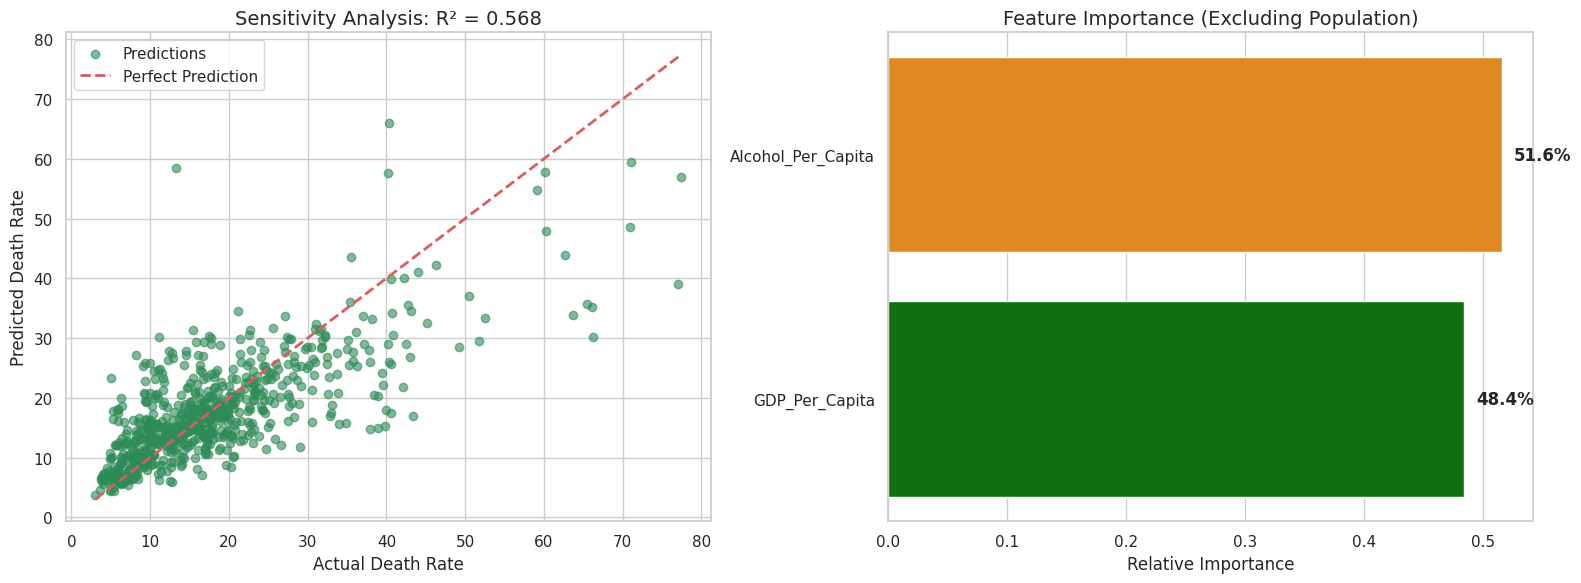


--- SENSITIVITY ANALYSIS RESULTS ---
R-squared Score (without Population): 0.5679
Root Mean Squared Error (RMSE):       7.3393



In [21]:
# Data Preparation (excluding 'Population' this time)
X_sens = df[['GDP_Per_Capita', 'Alcohol_Per_Capita']]
y_sens = df['Death_Rate_Per_100k']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_sens, y_sens, test_size=0.2, random_state=42)

# Scaling.
scaler_s = StandardScaler()
X_train_scaled_s = scaler_s.fit_transform(X_train_s)
X_test_scaled_s = scaler_s.transform(X_test_s)

# Training Optimized Random Forest
rf_sens = RandomForestRegressor(n_estimators = 200, max_depth = None, min_samples_split = 2, random_state = 42)
rf_sens.fit(X_train_scaled_s, y_train_s)

# Predictions and Metrics
y_pred_s = rf_sens.predict(X_test_scaled_s)
r2_s = r2_score(y_test_s, y_pred_s)
rmse_s = np.sqrt(mean_squared_error(y_test_s, y_pred_s))

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Actual vs Predicted (Sensitivity).
axes[0].scatter(y_test_s, y_pred_s, alpha=0.6, color='seagreen', label='Predictions')
min_val = min(y_test_s.min(), y_pred_s.min())
max_val = max(y_test_s.max(), y_pred_s.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_title(f'Sensitivity Analysis: R² = {r2_s:.3f}', fontsize=14)
axes[0].set_xlabel('Actual Death Rate')
axes[0].set_ylabel('Predicted Death Rate')
axes[0].legend()

# Plot 2: Feature Importance (Sensitivity).
importances_s = rf_sens.feature_importances_
importance_df_s = pd.DataFrame({'Feature': X_sens.columns, 'Importance': importances_s}).sort_values(by='Importance', ascending=False)

sns.barplot(ax=axes[1], x='Importance', y='Feature', data=importance_df_s, hue='Feature', palette={'GDP_Per_Capita': 'green', 'Alcohol_Per_Capita': 'darkorange'}, legend=False)

# Exact percentage representation.
for p in axes[1].patches:
    width = p.get_width()
    axes[1].text(width + 0.01, p.get_y() + p.get_height()/2, f'{width*100:.1f}%', ha='left', va='center', fontweight='bold')

# Title and Labels.
axes[1].set_title('Feature Importance (Excluding Population)', fontsize = 14)
axes[1].set_xlabel('Relative Importance')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print(f"\n--- SENSITIVITY ANALYSIS RESULTS ---")
print(f"R-squared Score (without Population): {r2_s:.4f}")
print(f"Root Mean Squared Error (RMSE):       {rmse_s:.4f}\n")

## 7. Final Machine Learning Conclusion

Predictive modeling phase has concluded with the following observations:

**1. General Performance:** The primary model reached an **$R^2$ of 0.9031**. This suggests that when we include country scale (Population) along with wealth and behavior, the model can capture the general patterns of traffic death rates quite effectively.

**2. Sensitivity Check (Removing Population):** When the `Population` feature was removed to avoid any **mathematical shortcut**, the $R^2$ score settled at **0.5679**. While this is a drop from the initial model, explaining more than half of the variance using only **two variables** (`GDP_Per_Capita` and `Alcohol_Per_Capita`) is a reasonable and acceptable result for this analysis. It proves that the model isn't just relying on country size but is actually finding value in the socio-economic indicators.

**3. The Role of Alcohol vs. GDP:** Interestingly, in both versions of the model, **`Alcohol_Per_Capita`** showed a higher predictive importance than GDP. It is important to emphasize that this variable is in a **strong negative correlation** with traffic death rates in this dataset. This indicates that the algorithm relies more heavily on alcohol consumption levels than on wealth to distinguish between different fatality rate brackets, treating it as the primary indicator for its predictions.

**Final Note:** The non-linear modeling approach successfully established a mathematical link between the selected features and traffic safety. Even with a simplified set of variables, the results show clear associations between a nation's economic status, alcohol consumption metrics, and traffic fatality rates. These findings confirm that global safety outcomes are not random and can be modeled with high $R^2$ score using behavioral and socio-economic indicators.